Add Lemmatization and Emoji handling as tuning

#Import Libraries & Load Data

In [49]:
!pip install contractions
!pip install wordcloud

%load_ext cuml.accel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import contractions
import string
import re
import joblib
import sys
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from scipy.stats import randint, uniform
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

In [ ]:
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

In [ ]:
# data = pd.read_table("amazon_reviews_us_Camera_v1_00.tsv")
data = pd.read_csv("amazon_reviews_us_Camera_v1_00.tsv", sep='\t', nrows=50000)
data

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,2975964,R1NBG94582SJE2,B00I01JQJM,860486164,GoPro Rechargeable Battery 2.0 (HERO3/HERO3+ o...,Camera,5,0,0,N,Y,Five Stars,ok,2015-08-31
1,US,23526356,R273DCA6Y0H9V7,B00TCO0ZAA,292641483,Professional 58mm Center Pinch Lens Cap for CA...,Camera,5,0,0,N,Y,Love it!!!,"Perfect, even sturdier than the original!",2015-08-31
2,US,52764145,RQVOXO7WUOFK6,B00B7733E0,75825744,Spy Tec Z12 Motion Activated Intelligent Secur...,Camera,2,1,1,N,Y,Another Motion Detect Fail,"If the words, &#34;Cheap Chinese Junk&#34; com...",2015-08-31
3,US,47348933,R1KWKSF21PO6HO,B006ZN4U34,789352955,"Celestron UpClose G2 10x25 Monocular, Black (7...",Camera,5,0,0,N,Y,Exactly what I wanted and expected.,Exactly what I wanted and expected. Perfect fo...,2015-08-31
4,US,33680700,R38H3UO1J190GI,B00HUEBGMU,19067902,Vidpro XM-L Wired Lavalier microphone - 20' Au...,Camera,5,1,1,N,Y,Good mic at a Good Price...Not Canon Though.,I will look past the fact that they tricked me...,2015-08-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,US,42283356,R369W9JLH9K3RR,B00TEA6FOW,365523865,80 mm Solar System Imaging Bundle - Beginners ...,Camera,1,0,1,N,Y,One Star,Glorified binocular...Unable to see clearly mo...,2015-08-04
49996,US,2500622,R1C88OZ0SJVH9N,B004U7JYXS,905624752,"Fuji 96090 Instax Mini Instant Film, 10 Sheet,...",Camera,5,0,0,N,Y,Five Stars,Great!,2015-08-04
49997,US,8245526,RTXFUML1188U6,B00007E80N,910098472,NIKON NS1 Wide Neck Strap,Camera,4,0,0,N,Y,Four Stars,Fits well. The only issue is leather quality.,2015-08-04
49998,US,13567957,R18SCHF9WQJY2E,B00BXEB3BW,667618013,Adapter Ring For Nikon AI AF G lens to Fujifil...,Camera,4,0,0,N,Y,"Should be 3.5 stars, but I'll round up.",It does what it says it does. It allows you to...,2015-08-04


#Initial Exploratory Data Analysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        50000 non-null  object
 1   customer_id        50000 non-null  int64 
 2   review_id          50000 non-null  object
 3   product_id         50000 non-null  object
 4   product_parent     50000 non-null  int64 
 5   product_title      50000 non-null  object
 6   product_category   50000 non-null  object
 7   star_rating        50000 non-null  int64 
 8   helpful_votes      50000 non-null  int64 
 9   total_votes        50000 non-null  int64 
 10  vine               50000 non-null  object
 11  verified_purchase  50000 non-null  object
 12  review_headline    50000 non-null  object
 13  review_body        49989 non-null  object
 14  review_date        50000 non-null  object
dtypes: int64(5), object(10)
memory usage: 5.7+ MB


In [ ]:
data.isna().sum()

,0
marketplace,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0
total_votes,0


There are 11 rows with empty review_body cells.

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# Check whether all the products are Cameras
data['product_category'][data['product_category'] == 'Camera'].count()

np.int64(50000)

All the product reviews are of Cameras.

In [ ]:
data['product_id'].nunique()

20900

There are 20900 different Cameras

#Data Handling and Cleaning

##Selecting the column with the features (Review columns)

In [ ]:
cleaned_data = data[["review_headline", "review_body","star_rating"]]
cleaned_data

,review_headline,review_body,star_rating
0,Five Stars,ok,5
1,Love it!!!,"Perfect, even sturdier than the original!",5
2,Another Motion Detect Fail,"If the words, &#34;Cheap Chinese Junk&#34; com...",2
3,Exactly what I wanted and expected.,Exactly what I wanted and expected. Perfect fo...,5
4,Good mic at a Good Price...Not Canon Though.,I will look past the fact that they tricked me...,5
...,...,...,...
49995,One Star,Glorified binocular...Unable to see clearly mo...,1
49996,Five Stars,Great!,5
49997,Four Stars,Fits well. The only issue is leather quality.,4
49998,"Should be 3.5 stars, but I'll round up.",It does what it says it does. It allows you to...,4


##Combine `review_headline` with `review_body`

In [ ]:
cleaned_data["review_body"] = cleaned_data["review_body"].fillna("")
cleaned_data[cleaned_data["review_body"].isna()]

,review_headline,review_body,star_rating


In order to emphasize the weight of `review_headline`, its string is duplicated when combining `review_headline` and `review_body`

In [ ]:
# cleaned_data["review"] = cleaned_data["review_headline"] + " " + cleaned_data["review_body"]
# cleaned_data

#Duplicating review headline to emphasize review_headline
cleaned_data["review"] = cleaned_data["review_headline"] + " " + cleaned_data["review_headline"] + " " + cleaned_data["review_body"]

In [ ]:
review_data = cleaned_data[['review', 'star_rating']]
review_data

,review,star_rating
0,Five Stars Five Stars ok,5
1,"Love it!!! Love it!!! Perfect, even sturdier t...",5
2,Another Motion Detect Fail Another Motion Dete...,2
3,Exactly what I wanted and expected. Exactly wh...,5
4,Good mic at a Good Price...Not Canon Though. G...,5
...,...,...
49995,One Star One Star Glorified binocular...Unable...,1
49996,Five Stars Five Stars Great!,5
49997,Four Stars Four Stars Fits well. The only issu...,4
49998,"Should be 3.5 stars, but I'll round up. Should...",4


#Exploratory Data Analysis

###Star Rating Distribution

In [ ]:
review_data["star_rating"].value_counts().sort_index()

,count
star_rating,
1,4750
2,2382
3,3580
4,7772
5,31516


Text(0.5, 1.0, 'Review Rating Distribution')

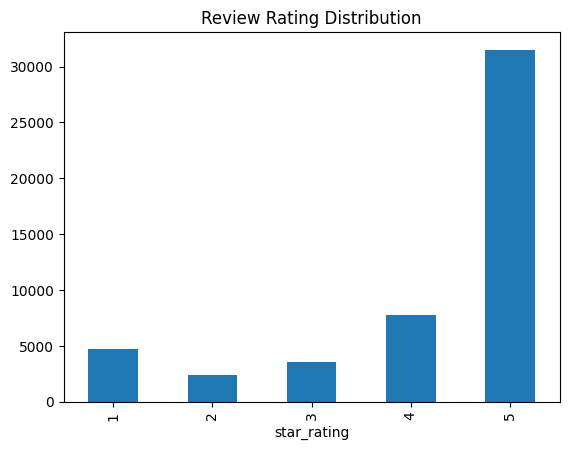

In [ ]:
review_data["star_rating"].value_counts().sort_index().plot(kind="bar");
plt.title("Review Rating Distribution")

Data is heavily imbalanced (negatively skewed). The data has an overwhelming amount of 5 star reviews compared to other star ratings. This means that most of the cameras have good reviews.

In [ ]:
review_data.describe()

,star_rating
count,50000.000000
mean,4.178440
std,1.309837
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
# Using the full dataset to see the star rating distribution of each product.
table = pd.crosstab(data['product_id'], data['star_rating'])
table.sort_values(by=5, ascending=False).head(20)

star_rating,1,2,3,4,5
product_id,,,,,
B00JAJ9U8K,23,24,31,72,272
B0050R67U0,3,1,2,13,117
B00H3Q8QB4,6,7,4,13,112
B0039BPG1A,5,1,5,26,94
B00WBJGUA2,43,11,10,50,87
B00OAAUZO2,7,1,3,13,73
B004U7JYXS,3,3,3,11,69
B002VPE1WK,2,10,9,12,65
B00MNG37C2,13,5,8,14,64


In [ ]:
table.sort_values(by=1, ascending=False).head(20)

star_rating,1,2,3,4,5
product_id,,,,,
B00WBJGUA2,43,11,10,50,87
B00JAJ9U8K,23,24,31,72,272
B006ZP8UOW,16,8,5,9,20
B004P8K24W,16,9,15,11,32
B009TQ4L5Q,14,2,1,0,2
B00VSITBJO,13,2,5,6,45
B00MNG37C2,13,5,8,14,64
B00452V66G,11,7,2,10,25
B00J8RM35Q,10,2,10,5,11


There aren't any products with an overwhelmingly amount of negative star ratings (ratings below 3). The table shows that most products seem to have good ratings (ratings above 3)

##Wordcloud Visualization

###Wordcloud of all the Reviews

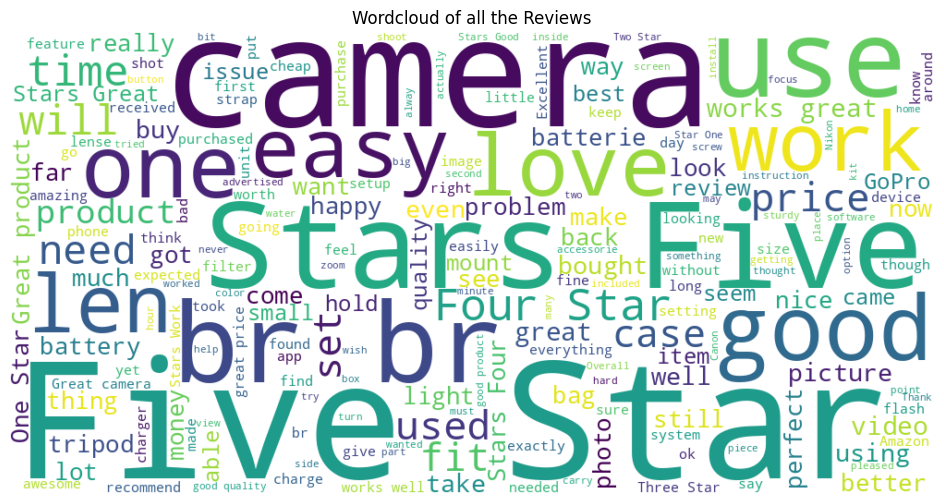

In [ ]:
text = " ".join(review_data["review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="viridis",
    random_state=42
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of all the Reviews")
plt.show()

**Initial Analysis**
*   br br raises suspicion that the reviews might contain HTML line breaks in them.

In [ ]:
review_data.loc[
    review_data["review"].str.contains(r"<br\s*/?>", case=False, regex=True, na=False),
    "review"
].iloc[0]

"Another Motion Detect Fail Another Motion Detect Fail If the words, &#34;Cheap Chinese Junk&#34; come to your mind when you see this, then congratulate yourself.  You're pretty close.  One of the most important features of a 'security camera&#34; is the ability to detect motion and record, especially when running on battery and limited storage space.  I tested the motion detect on this camera in a few different environments so far (i.e. low light, indoors, outdoors, etc..) and all I got was a SD card full of video triggers.  All the testing was done with the low motion sensitivity setting.  I can't even imagine what the high one would be.<br />As others said, the low light operation is poor.  I did one of my tests outdoors as the sun was setting.  It was good until a point - then the camera started having seizures..it got fuzzy, went to black and white...back to color...then ultimately stabilized with lines across the screen.<br />Another oddity I noticed was that the firmware reporte

It is confirmed that some of the reviews definitely have the HTML line break in their text.

In [ ]:
review_data["review"].str.contains(r"<br\s*/?>", case=False, regex=True, na=False).sum()

np.int64(5353)

Over 5000 reviews contain the HTML line breaks. Thus, it needs to be removed to avoid it affecting the machine learning models.

In [ ]:
review_data["review"] = review_data["review"].str.replace(
    r"<br\s*/?>",
    " ",
    regex=True,
    case=False
)

In [ ]:
review_data["review"].str.contains(r"<br\s*/?>", case=False, regex=True, na=False).sum()

np.int64(0)

Wordcloud of all the Reviews without HTML line breaks

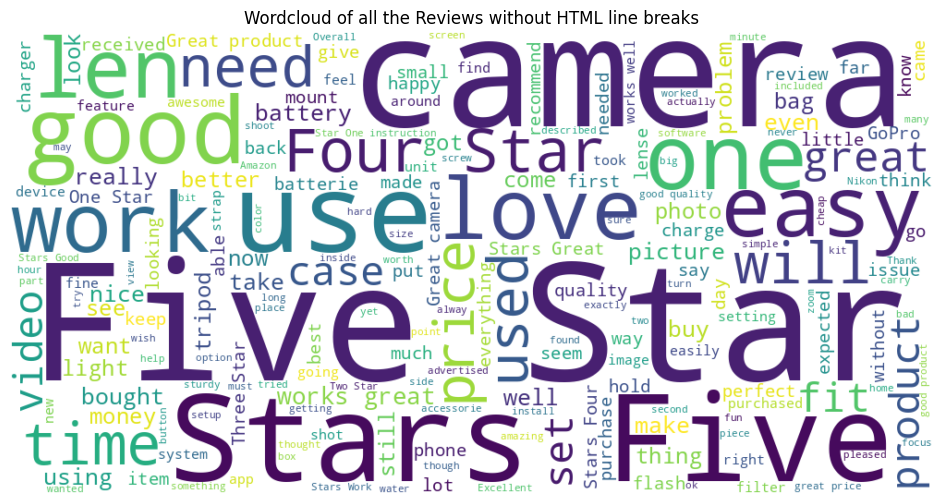

In [ ]:
text = " ".join(review_data["review"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="viridis",
    random_state=42
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of all the Reviews without HTML line breaks")
plt.show()

**Insights**
*   "Five Star" seems to be the most common phrase in the reviews, which confirms that most of the review star ratings are 5 stars.
*   Camera is also a common word that shows up in the reviews, which validates that the reviews are directed towards the right product category.

###Wordcloud of Reviews with 4 or 5 Star Ratings

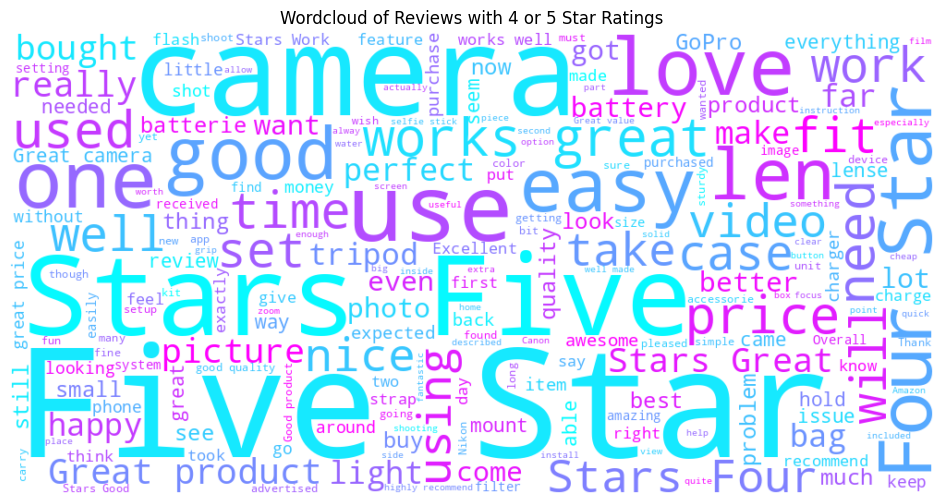

In [ ]:
text = " ".join(review_data["review"][review_data["star_rating"] >= 4])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="cool",
    random_state=42
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Reviews with 4 or 5 Star Ratings")
plt.show()

###Wordcloud of Reviews with 3 Star Ratings

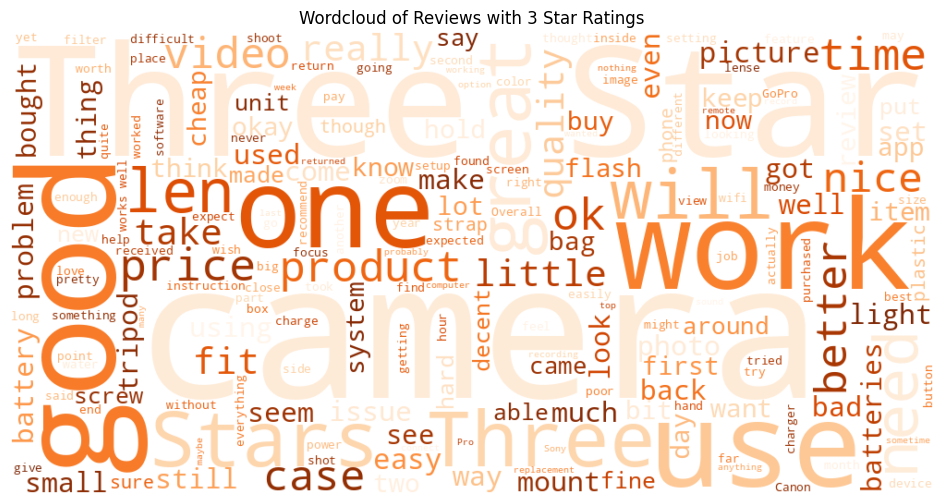

In [ ]:
text = " ".join(review_data["review"][review_data["star_rating"] == 3])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="Oranges",
    random_state=42
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Reviews with 3 Star Ratings")
plt.show()

###Wordcloud of Reviews with 1 or 2 Star Ratings

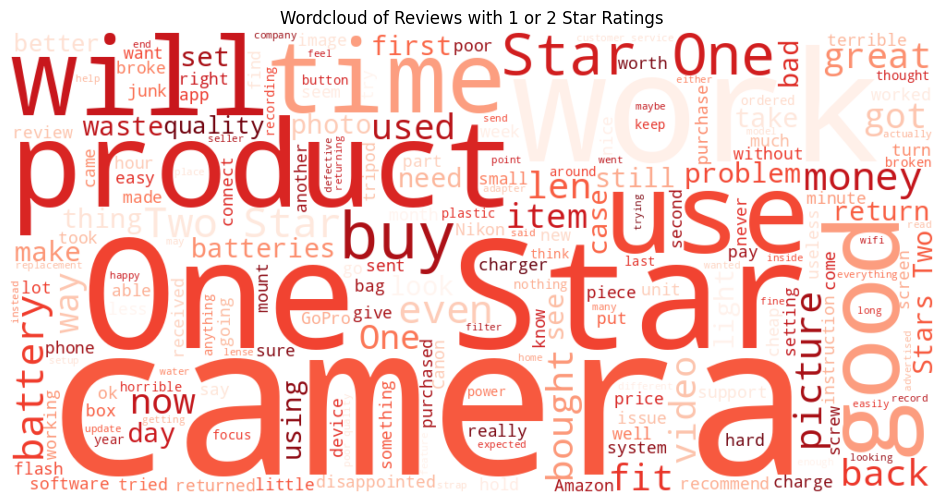

In [ ]:
text = " ".join(review_data["review"][review_data["star_rating"] <= 2])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200,
    colormap="Reds",
    random_state=42
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Reviews with 1 or 2 Star Ratings")
plt.show()

#Data Preprocessing

In [ ]:
punct_table = str.maketrans('', '', string.punctuation)

def process_message(message):
    message = message.lower() # Can be removed because TFIDF already does this
    message = contractions.fix(message) # expands the contracted words
    message = message.translate(punct_table) # eliminates punctuations
    message = re.sub(r'(.)\1{2,}', r'\1\1', message) # normalizes words with repeated letters into 2 letters only e.g. "soooo" to "soo"
    message = " ".join(message.split()) # eliminates extra whitespaces
    return message

review_data['review'] = review_data["review"].apply(process_message)

review_data.head()

,review,star_rating
0,five stars five stars ok,5
1,love it love it perfect even sturdier than the...,5
2,another motion detect fail another motion dete...,2
3,exactly what i wanted and expected exactly wha...,5
4,good mic at a good pricenot canon though good ...,5


#Encoding
Encoding is needed in order for XGBoost to be able to process the star_rating. Thus, Label Encoding is used to fit the requirements.

In [ ]:
le = LabelEncoder()

le_star_rating = le.fit_transform(cleaned_data["star_rating"])

#Train Test Split

In [ ]:
X = cleaned_data["review"]
y = le_star_rating

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Feature Extraction

In [ ]:
#Defining the TF-IDF function
tfidf = TfidfVectorizer(preprocessor=process_message,
                        max_features=30000,
                        ngram_range=(1, 2),
                        min_df=5,
                        max_df=0.9,
                        sublinear_tf=True,
                        norm="l2",
                        dtype=np.float32)

#Model Pipeline and Evaluation

##Creating Evaluation Metrics Function

In [ ]:
#Create a function to collect eval metrics
def evaluate_preds(y_true: np.array,
                   y_preds: np.array) -> dict:
    """
    Performs evaluation comparison on y_true labels vs. y_pred labels.

    Returns several metrics in the form of a dictionary.
    """
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds, average='weighted')
    recall = recall_score(y_true, y_preds, average='weighted')
    f1 = f1_score(y_true, y_preds, average='weighted')
    macro_f1 = f1_score(y_true, y_preds, average='macro')
    metric_dict = {"Accuracy": round(accuracy, 2),
                   "Precision": round(precision, 2),
                   "Recall": round(recall, 2),
                   "F1-Score": round(f1, 2),
                   "Macro F1-Score": round(macro_f1, 2)}
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 score: {f1:.2f}")
    print(f"Macro F1 score: {macro_f1:.2f}")

    return metric_dict

In [ ]:
col = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Macro F1-Score']
base_model_results = pd.DataFrame(columns = col)

##Baseline Model - Multinomial Naive Bayes

In [ ]:
#Creating baseline model pipeline
baseline = Pipeline(steps=[("tfidf", tfidf),
                           ("clf", MultinomialNB())])

baseline.fit(X_train, y_train)

# Predict on the test data
y_pred = baseline.predict(X_test)

# Evaluate the model
baseline_metrics = evaluate_preds(y_test, y_pred)
baseline_metrics['Model'] = baseline.named_steps["clf"].__class__.__name__

Accuracy: 78.14%
Precision: 0.80
Recall: 0.78
F1 score: 0.75
Macro F1 score: 0.59


In [ ]:
base_model_results.loc[len(base_model_results)] = baseline_metrics

In [ ]:
baseline_metrics

{'Accuracy': 0.78,
 'Precision': 0.8,
 'Recall': 0.78,
 'F1-Score': 0.75,
 'Macro F1-Score': 0.59,
 'Model': 'MultinomialNB'}

##Logistic Regression

In [ ]:
#Creating Logistic Regression pipeline
logistic_regression = Pipeline(steps=[("tfidf", tfidf),
                           ("clf", LogisticRegression())])

logistic_regression.fit(X_train, y_train)

# Predict on the test data
y_pred = logistic_regression.predict(X_test)

# Evaluate the model
lr_metrics = evaluate_preds(y_test, y_pred)
lr_metrics['Model'] = logistic_regression.named_steps["clf"].__class__.__name__
base_model_results.loc[len(base_model_results)] = lr_metrics

Accuracy: 81.86%
Precision: 0.81
Recall: 0.82
F1 score: 0.80
Macro F1 score: 0.65


##Support Vector Machine (SVM)

In [ ]:
#Creating LinearSVC pipeline
linear_svc = Pipeline(steps=[("tfidf", tfidf),
                           ("clf", LinearSVC())])

linear_svc.fit(X_train, y_train)

# Predict on the test data
y_pred = linear_svc.predict(X_test)

# Evaluate the model
lsvc_metrics = evaluate_preds(y_test, y_pred)
lsvc_metrics['Model'] = linear_svc.named_steps["clf"].__class__.__name__
base_model_results.loc[len(base_model_results)] = lsvc_metrics

Accuracy: 81.21%
Precision: 0.80
Recall: 0.81
F1 score: 0.80
Macro F1 score: 0.65


##Random Forest

In [ ]:
#Creating RandomForestClassifier pipeline
random_forest = Pipeline(steps=[("tfidf", tfidf),
                           ("clf", RandomForestClassifier())])

random_forest.fit(X_train, y_train)

# Predict on the test data
y_pred = random_forest.predict(X_test)

# Evaluate the model
random_forest_metrics = evaluate_preds(y_test, y_pred)
random_forest_metrics['Model'] = random_forest.named_steps["clf"].__class__.__name__
base_model_results.loc[len(base_model_results)] = random_forest_metrics

Accuracy: 77.34%
Precision: 0.81
Recall: 0.77
F1 score: 0.74
Macro F1 score: 0.58


##XGBoost

In [ ]:
#Creating XGBoost pipeline
xgboost = Pipeline(steps=[("tfidf", tfidf),
                           ("clf", XGBClassifier())])

xgboost.fit(X_train, y_train)

# Predict on the test data
y_pred = xgboost.predict(X_test)

# Evaluate the model
xgboost_metrics = evaluate_preds(y_test, y_pred)
xgboost_metrics['Model'] = xgboost.named_steps["clf"].__class__.__name__
base_model_results.loc[len(base_model_results)] = xgboost_metrics

Accuracy: 80.57%
Precision: 0.79
Recall: 0.81
F1 score: 0.79
Macro F1 score: 0.64


In [42]:
xgboost_metrics

{'Accuracy': 0.81,
 'Precision': 0.79,
 'Recall': 0.81,
 'F1-Score': 0.79,
 'Macro F1-Score': 0.64,
 'Model': 'XGBClassifier'}

##Performance Evaluation

In [43]:
base_model_results

,Model,Accuracy,Precision,Recall,F1-Score,Macro F1-Score
0,MultinomialNB,0.78,0.80,0.78,0.75,0.59
1,LogisticRegression,0.82,0.81,0.82,0.80,0.65
2,LinearSVC,0.81,0.80,0.81,0.80,0.65
3,RandomForestClassifier,0.77,0.81,0.77,0.74,0.58
4,XGBClassifier,0.81,0.79,0.81,0.79,0.64


#Hyperparameter Tuning and Optimization

In [44]:
best_model_results = pd.DataFrame(columns = col)

##Baseline Model - Multinomial Naive Bayes

In [45]:
baseline_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__max_features": [20000, 30000],
    "clf__alpha": [0.1, 0.5, 1.0]
}

baseline_grid_search = GridSearchCV(
    estimator=baseline,
    param_grid=baseline_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

baseline_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(dtype=<class 'numpy.float32'>,
                                                        max_df=0.9,
                                                        max_features=30000,
                                                        min_df=5,
                                                        ngram_range=(1, 2),
                                                        preprocessor=<function process_message at 0x7e0844ea51c0>,
                                                        sublinear_tf=True)),
                                       ('clf', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'clf__alpha': [0.1, 0.5, 1.0],
                         'tfidf__max_df': [0.9, 0.95],
                         'tfidf__max_features': [20000, 30000],
                         'tfidf__min_df': [3, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [46]:
best_baseline_model = baseline_grid_search.best_estimator_
best_baseline_params = baseline_grid_search.best_params_
best_baseline_score = baseline_grid_search.best_score_

print("Best parameters:", best_baseline_params)
print("Best CV macro F1:", best_baseline_score)

y_pred_best_baseline = best_baseline_model.predict(X_test)
best_baseline_metrics = evaluate_preds(y_test, y_pred_best_baseline)
best_baseline_metrics['Model'] = best_baseline_model.named_steps["clf"].__class__.__name__
best_model_results.loc[len(best_model_results)] = best_baseline_metrics

Best parameters: {'clf__alpha': 0.1, 'tfidf__max_df': 0.9, 'tfidf__max_features': 20000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV macro F1: 0.6248272334044842
Accuracy: 80.65%
Precision: 0.79
Recall: 0.81
F1 score: 0.79
Macro F1 score: 0.64


In [47]:
best_model_results.loc[len(best_model_results)] = {"Model": "MultinomialNB",
                                                   "Accuracy": 0.81,
                                                   "Precision": 0.79,
                                                   "Recall": 0.81,
                                                   "F1-Score": 0.79,
                                                   "Macro F1-Score": 0.64}

##Logistic Regression

In [50]:
lr_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__max_features": [20000, 30000],
    "clf__C": [0.1, 0.5, 1, 2, 5],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["lbfgs", "saga"],
}

lr_grid_search = GridSearchCV(
    estimator=logistic_regression,
    param_grid=lr_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

lr_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(dtype=<class 'numpy.float32'>,
                                                        max_df=0.9,
                                                        max_features=30000,
                                                        min_df=5,
                                                        ngram_range=(1, 2),
                                                        preprocessor=<function process_message at 0x7e0844ea51c0>,
                                                        sublinear_tf=True)),
                                       ('clf', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 0.5, 1, 2, 5],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__solver': ['lbfgs', 'saga'],
                         'tfidf__max_df': [0.9, 0.95],
                         'tfidf__max_features': [20000, 30000],
                         'tfidf__min_df': [3, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [51]:
best_lr_model = lr_grid_search.best_estimator_
best_lr_params = lr_grid_search.best_params_
best_lr_score = lr_grid_search.best_score_

print("Best parameters:", best_lr_params)
print("Best CV macro F1:", best_lr_score)

y_pred_best_lr = best_lr_model.predict(X_test)
best_lr_metrics = evaluate_preds(y_test, y_pred_best_lr)
best_lr_metrics['Model'] = best_lr_model.named_steps["clf"].__class__.__name__
best_model_results.loc[len(best_model_results)] = best_lr_metrics

Best parameters: {'clf__C': 5, 'clf__class_weight': None, 'clf__solver': 'lbfgs', 'tfidf__max_df': 0.9, 'tfidf__max_features': 20000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV macro F1: 0.638610548059793
Accuracy: 81.15%
Precision: 0.80
Recall: 0.81
F1 score: 0.80
Macro F1 score: 0.65


In [52]:
best_model_results.loc[len(best_model_results)] = {"Model": "LogisticRegression",
                                                    "Accuracy": 0.81,
                                                    "Precision": 0.80,
                                                    "Recall": 0.81,
                                                    "F1-Score": 0.80,
                                                    "Macro F1-Score": 0.65}

##Support Vector Machine

In [ ]:
lsvc_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__max_features": [20000, 30000],
    "clf__C": [0.1, 0.5, 1, 2, 5],
    "clf__class_weight": [None, "balanced"]
}

lsvc_grid_search = GridSearchCV(
    estimator=linear_svc,
    param_grid=lsvc_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

lsvc_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


In [ ]:
best_lsvc_model = lsvc_grid_search.best_estimator_
best_lsvc_params = lsvc_grid_search.best_params_
best_lsvc_score = lsvc_grid_search.best_score_

print("Best parameters:", best_lsvc_params)
print("Best CV macro F1:", best_lsvc_score)

y_pred_best_lsvc = best_lsvc_model.predict(X_test)
best_lsvc_metrics = evaluate_preds(y_test, y_pred_best_lsvc)
best_lsvc_metrics['Model'] = best_lsvc_model.named_steps["clf"].__class__.__name__
best_model_results.loc[len(best_model_results)] = best_lsvc_metrics

In [ ]:
best_model_results.loc[len(best_model_results)] = {"Model": "LinearSVC",
                                                     "Accuracy": 0.81,
                                                     "Precision": 0.81,
                                                     "Recall": 0.81,
                                                     "F1-Score": 0.81,
                                                     "Macro F1-Score": 0.65}

##Random Forest

ngram_range and max_df were already optimal parameters for the previous tuned models. Thus, there is little value in searching through them again.

In [ ]:
random_forest_grid = {
    "tfidf__min_df": [3, 5],
    "tfidf__max_features": [20000, 30000],

    "clf__n_estimators": [200, 300],
    "clf__max_depth": [20, None],
    "clf__class_weight": [None, "balanced"]
}

random_forest_grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=random_forest_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

random_forest_grid_search.fit(X_train, y_train)

In [ ]:
best_random_forest_model = random_forest_grid_search.best_estimator_
best_random_forest_params = random_forest_grid_search.best_params_
best_random_forest_score = random_forest_grid_search.best_score_

print("Best parameters:", best_random_forest_params)
print("Best CV macro F1:", best_random_forest_score)

y_pred_best_rf = best_random_forest_model.predict(X_test)
best_random_forest_metrics = evaluate_preds(y_test, y_pred_best_rf)
best_random_forest_metrics['Model'] = best_random_forest_model.named_steps["clf"].__class__.__name__
best_model_results.loc[len(best_model_results)] = best_random_forest_metrics

##XGBoost

In [ ]:
xgboost_grid = {
    "tfidf__min_df": [3, 5],
    "tfidf__max_features": [20000, 30000],

    "clf__n_estimators": randint(100, 301),
    "clf__learning_rate": uniform(0.03, 0.1),
    "clf__max_depth": randint(3, 7),
    "clf__min_child_weight": randint(1, 5),
    "clf__subsample": uniform(0.7, 0.3),
    "clf__colsample_bytree": uniform(0.7, 0.3)
}

xgboost_grid_search = RandomizedSearchCV(
    estimator=xgboost,
    param_distributions=xgboost_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

xgboost_grid_search.fit(X_train, y_train)

In [ ]:
best_xgboost_model = xgboost_grid_search.best_estimator_
best_xgboost_params = xgboost_grid_search.best_params_
best_xgboost_score = xgboost_grid_search.best_score_

print("Best parameters:", best_xgboost_params)
print("Best CV macro F1:", best_xgboost_score)

y_pred_best_xgboost = best_xgboost_model.predict(X_test)
best_best_xgboost_model_metrics = evaluate_preds(y_test, y_pred_best_xgboost)
best_best_xgboost_model_metrics['Model'] = best_xgboost_model.named_steps["clf"].__class__.__name__
best_model_results.loc[len(best_model_results)] = best_best_xgboost_model_metrics

##Performance Evaluation

In [ ]:
best_model_results

**Insights**
Logistic Regression and SVM proved to be the models with the highest Macro F1-Score, while Naive Bayes showed the highest spike in its Macro F1-Score.

###Per Class Performance Evaluation

####Logistic Regression

In [ ]:
report_dict = classification_report(y_test, y_pred_best_lr, output_dict=True)

df = pd.DataFrame(report_dict).transpose()
df

####Support Vector Machine

In [ ]:
report_dict = classification_report(y_test, y_pred_best_lsvc, output_dict=True)

df = pd.DataFrame(report_dict).transpose()
df

NameError: name 'classification_report' is not defined

#Conclusion

#Deployment

##Saving the Model

In [ ]:
joblib.dump(best_model,
            "models/review_rating_model.pkl")

##Creating the API